# Telco Customer Churn Prediction

## Project Overview

The dataset used in this project is the Telco Customer Churn dataset sourced from Kaggle.
It contains 7,043 records with 21 columns providing detailed information about customers 
and their service usage.

## Data Description

The dataset is organized into four key areas:

- **Demographics** — gender, age range, partner and dependent status
- **Account Information** — tenure, contract type, payment method, paperless billing, 
  monthly charges, and total charges
- **Services** — phone, multiple lines, internet, online security, online backup, 
  device protection, tech support, streaming TV and movies
- **Target Variable** — Churn: whether the customer left within the last month

## Goal

To predict whether an existing customer will churn in the near future using 
Logistic Regression and Random Forest classification models.



The workflow follows a standard ML pipeline:
- Exploratory Data Analysis (EDA)
- Data Cleaning and Handling Missing Values
- Data Visualization to identify patterns
- Feature Engineering
- Model Building — Logistic Regression and Random Forest
- Model Evaluation and Comparison

### Importing the data and EDA to study the data

In [1]:
import pandas as pd
data = pd.read_csv("C:/Users/Ayman/Desktop/G/Lock_in_period/Telco-Customer-Churn.csv")

In [2]:
print(data.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
print(data.shape)

(7043, 21)


In [4]:
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


#### Here the above output shows that there are no null values

In [5]:
print(data.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


As per the above output, the column TotalCharges is considered as an object whereas it actually contains
numeric values. So we first convert it to numeric type as shown below and then check for null values if any.


In [6]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors = "coerce")
print(data.isnull().sum())
print(data["TotalCharges"].dtypes)

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
float64


So, as per the above output there are 11 null values in the TotalCharges column
as these are very few in number we eliminate them completely.

In [7]:
data = data.dropna(subset = ["TotalCharges"])
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
print(data.dtypes)
print(data["Churn"].value_counts())

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object
Churn
No     5163
Yes    1869
Name: count, dtype: int64


We get the churn count above and then below we calculate its churn rate.

In [9]:
print(1869/(1869+5163)) #churn rate

0.26578498293515357


From the above output about data types, we observe that there are a lot of categorical columns of object types
so to deal with those efficiently, we will have to convert those to numeric type first.

In [10]:
data = data.drop("customerID", axis = 1) 

Also we drop the customerID column completely as it wont be of any use.

In [11]:
cat_cols = data.select_dtypes(include = "object").columns.tolist() #listing all the object type columns
print(cat_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = data.select_dtypes(include = "object").columns.tolist()

for col in cat_cols:
    data[col] = le.fit_transform(data[col])
print(data.dtypes)

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


By the above code, we converted all the object type columns to numeric type.

### Visuals

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

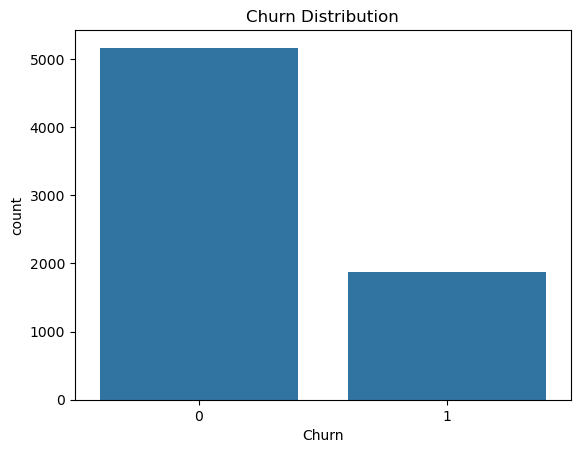

In [14]:
#churn distribution

sns.countplot(x="Churn",data = data)
plt.title("Churn Distribution")
plt.show()

The above bar chart tells us that almost around 1/3rd of customers churned last month.
This indicates that there is a customer retention problem worth solving.

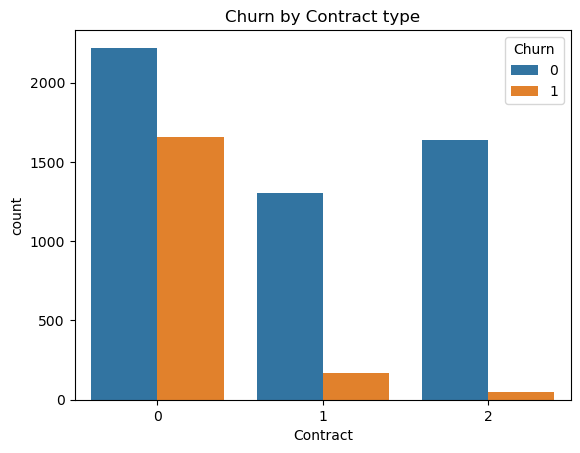

In [15]:
#Churn by contract type

sns.countplot(x = "Contract",hue = "Churn",data = data)
plt.title("Churn by Contract type")
plt.show()

The above chart shows that the customers who had Month-to-Month contract had a significantly higher churn rate
whereas those with longer contract terms stayed loyal.

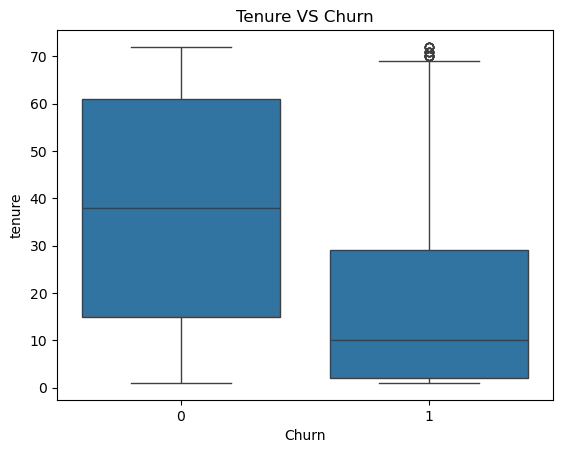

In [16]:
#tenure vs churn

sns.boxplot(x="Churn",y="tenure",data=data)
plt.title("Tenure VS Churn")
plt.show()

It is observed from the above chart that the customer that are churned are mostly the newer ones
and they most likely churn in the 0-20 months tenure. However, most customers with tenure of 30-50 months are loyal with the services.

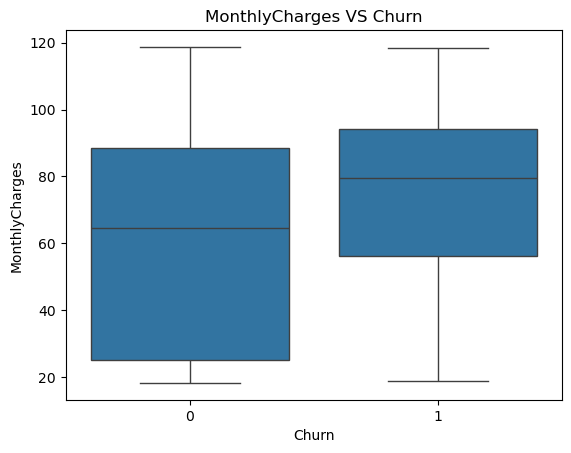

In [17]:
#MonthlyCharges vs churn

sns.boxplot(x="Churn",y="MonthlyCharges",data=data)
plt.title("MonthlyCharges VS Churn")
plt.show()

The boxplot indicates that customers who churn tend to have higher monthly charges compared to those who stay. This suggests that pricing may influence customer retention, particularly for newer customers who may be more sensitive to cost.

### Selecting features

In [18]:
features = ["Contract","tenure","MonthlyCharges"]
X = data[features] #independent variable
Y = data["Churn"] #dependent variable

print(X.shape)
print(Y.shape)

(7032, 3)
(7032,)


### Modeling

#### logistic regression

In [19]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(5625, 3)
(1407, 3)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix

In [21]:
model = LogisticRegression()
model.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
Y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(Y_test,Y_pred))
print("Confusion matrix :\n", confusion_matrix(Y_test,Y_pred))

Accuracy : 0.7782515991471215
Confusion matrix :
 [[919 114]
 [198 176]]


## Logistic Regression Results

The Logistic Regression model achieved an accuracy of 77.8% on 
the unseen test data (20% split).

Confusion Matrix Breakdown:
- True Negatives  (Predicted not churn, Actually not churn)     : 919
- True Positives  (Predicted Churn, Actually Churn) : 176
- False Positives (Predicted churn, not churn)  : 114
- False Negatives (Predicted not churn, Actually churn)  : 198

The model performed reasonably well as a baseline, correctly 
identifying 919 out of 1407 customers did not churn. However it struggled 
slightly more with identifying customers that churn, missing 198 actual 
customers that churn.

#### Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
Y_pred = rf_model.predict(X_test)

print("Accuracy :", accuracy_score(Y_test,Y_pred))
print("Confusion matrix :\n", confusion_matrix(Y_test,Y_pred))

Accuracy : 0.7569296375266524
Confusion matrix :
 [[888 145]
 [197 177]]


## Random Forest Results

The Random Forest model achieved an accuracy of 75.6% on 
the unseen test data (20% split).

Confusion Matrix Breakdown:
- True Negatives  (Predicted not churn, Actually not churn)     : 888
- True Positives  (Predicted Churn, Actually Churn) : 177
- False Positives (Predicted churn, not churn)  : 145
- False Negatives (Predicted not churn, Actually churn)  : 197

The model performed almost similar to the logistic regression model
but it was slightly behind in identifying the customers that did not churn.

## XGBoost

In [25]:
!pip install xgboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier()
xgb_model.fit(X_train,Y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [26]:
Y_pred = xgb_model.predict(X_test)

print("Accuracy :",accuracy_score(Y_test,Y_pred))
print("Confusion matrix :\n",confusion_matrix(Y_test,Y_pred))

Accuracy : 0.7768301350390903
Confusion matrix :
 [[903 130]
 [184 190]]


## Model Comparison and Conclusion

| Model               | Accuracy |
|---------------------|----------|
| Logistic Regression | 77.8%    |
| Random Forest       | 75.6%    |
| XGBoost             | 77.6%    |

Logistic Regression slightly outperformed Random Forest in terms of accuracy, indicating that the relationship between the input features and customer churn is largely linear. XGBoost achieved a comparable accuracy of 77.68%, performing on a similar level to the other models.

Since the differences in performance are minimal, no single model clearly stands out as the best. Logistic Regression offers simplicity and interpretability, while ensemble methods like Random Forest and XGBoost are better suited for capturing more complex patterns. Therefore, the final model choice should depend on business requirements and the trade-off between interpretability and model complexity.

Future Improvements
Add feature engineering (e.g., combining tenure and contract type)
Use cross-validation for more robust evaluation
Evaluate using F1-score and Recall alongside accuracy

# Cross Validation :

In [28]:
from sklearn.model_selection import cross_val_score

scores_lr = cross_val_score(model,X,Y,cv=5,scoring="accuracy")
print("LR individual fold scores :",scores_lr)
print("LR Mean accuracy :",scores_lr.mean())
print("LR Standard deviation :",scores_lr.std())

LR individual fold scores : [0.78464819 0.79459844 0.77382646 0.79231863 0.78733997]
LR Mean accuracy : 0.7865463376068247
LR Standard deviation : 0.007268890833957741


### Results of Cross validation (Logistic Regression) :
The mean CV accuracy (78.6%) is higher than single split accuracy (77.8%)
with a standard deviation of only 0.72%. Meaning, the single split test got
a comparatively higher test set. So using the mean CV accuracy is more optimal.

In [29]:
scores_rf = cross_val_score(rf_model,X,Y,cv=5,scoring="accuracy")
print("RF individual fold scores :",scores_rf)
print("RF Mean accuracy :",scores_rf.mean())
print("RF Standard deviation :",scores_rf.std())

RF individual fold scores : [0.74911158 0.76759062 0.75889047 0.74893314 0.75960171]
RF Mean accuracy : 0.7568255046652533
RF Standard deviation : 0.007066158372823802


### Results of Cross validation (Random Forest) :
The mean CV accuracy came out to be same as the single split accuracy which is 75.6%
with a standard deviation of only 0.7%. This tells us that random forest is a 
stable model.

In [30]:
scores_xgb = cross_val_score(xgb_model,X,Y,cv=5,scoring="accuracy")
print("XGB individual fold scores :",scores_xgb)
print("XGB Mean accuracy :",scores_xgb.mean())
print("XGB Standard deviation :",scores_xgb.std())

XGB individual fold scores : [0.77327647 0.79033404 0.75675676 0.77809388 0.78093883]
XGB Mean accuracy : 0.7758799985037219
XGB Standard deviation : 0.011062452189496697


### Results of Cross validation (XGBoost) :
Here again the mean CV accuracy and the single split accuracy came out to be almost same (77.6%)
with a standard deviation of 1.1%.

All three models show low standard deviation (under 1.1%)
indicating the Churn dataset is stable and well-behaved.
Cross validation confirms LR as the most reliable model
with lowest std (0.72%) and highest mean accuracy (78.6%)